## Packages

In [1]:
import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.3 scipy==1.9.1 pandas==1.5.0 scikit-learn==1.1.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


In [2]:
import batchglm.api as glm
import diffxpy.api as de

print("batchglm version "+glm.__version__)
print("diffpy version "+de.__version__)

batchglm version v0.7.4
diffpy version refs/pull/219/head


## Directory variables

In [3]:
import glob
import os
from pathlib import Path

sample_directory = './gex_vdj/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [4]:
plt.rcParams['figure.figsize']=(6,6) #rescale figures
sc.settings.set_figure_params(dpi=100, dpi_save=600, color_map='viridis', vector_friendly=True, format='eps')
### you can set a default figure directory here for saving output
sc.settings.figdir = "./analysis_output/figures_scanpy/"
## Figure directory for matplotlib figures/axes
save_figure_sc = "./analysis_output/figures_scanpy/"
#Use
#plt.savefig(save_figure + 'image.pdf')
save_figure_ir = "./analysis_output/figures_scirpy/"
#csv directory
read_csv = './analysis_output/saved_tables/'
save_csv = r'./analysis_output/saved_tables/'

## Custom functions

In [5]:
def clr_normalize_each_cell(adata, inplace=True):
    """Normalize count vector for each cell, i.e. for each row of .X"""

    import numpy as np
    import scipy

    def seurat_clr(x):
        # TODO: support sparseness
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()

    # apply to dense or sparse matrix, along axis. returns dense matrix
    adata.X = np.apply_along_axis(
        seurat_clr, 1, (adata.X.A if scipy.sparse.issparse(adata.X) else adata.X)
    )
    return adata

## Load data

In [6]:
# define sample metadata. Usually read from a file.
samples = {
    "_2": {"experiment": "1_naive", "group": "naive_exp1"},
    "_3": {"experiment": "2_naive", "group": "naive_exp2"},
    "_6": {"experiment": "3_naive", "group": "naive_exp3"},
    "_7": {"experiment": "4_naive", "group": "naive_exp4"},
}

In [7]:
for sample, sample_meta in samples.items():
    print(sample)

_2
_3
_6
_7


In [8]:
# Create a list of AnnData objects (one for each sample)
adatas = []
for sample, sample_meta in samples.items():
    gex_file = glob.glob(f'{sample_directory}/GEX*{sample}*/outs/filtered_feature_bc_matrix/')[0]
    tcr_file = glob.glob(f'{sample_directory}/VDJ*{sample}*/outs/*annotations.json')[0]
    adata = sc.read_10x_mtx(gex_file,
                            var_names='gene_symbols',      # use gene symbols for the variable names (variables-axis index)
                            cache=True, gex_only=False)   # write a cache file for faster subsequent reading
    adata_tcr = ir.io.read_10x_vdj(tcr_file)
    change_cat = adata_tcr.obs.columns.tolist()           #NaN values in VDJ data can mess up analysis for some reason
    for i in change_cat:                                   #here all NaN (basically for TCR chain calls) are replaced by 'None'
        adata_tcr.obs[i]=adata_tcr.obs[i].astype(str)
        adata_tcr.obs[i]=adata_tcr.obs[i].fillna('None')
        adata_tcr.obs[i]=adata_tcr.obs[i].replace('nan' ,'None')
        adata_tcr.obs[i]=adata_tcr.obs[i].astype('category')
    ir.pp.merge_with_ir(adata, adata_tcr)
    adata.obs["experiment"] = sample_meta["experiment"]
    adata.obs["group"] = sample_meta["group"]
    # concatenation only works with unique gene names
    adata.var_names_make_unique()
    adatas.append(adata)

... reading from cache file cache\gex_vdj-GEX_2-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache\gex_vdj-GEX_3-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache\gex_vdj-GEX_6-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache\gex_vdj-GEX_7-outs-filtered_feature_bc_matrix-matrix.h5ad


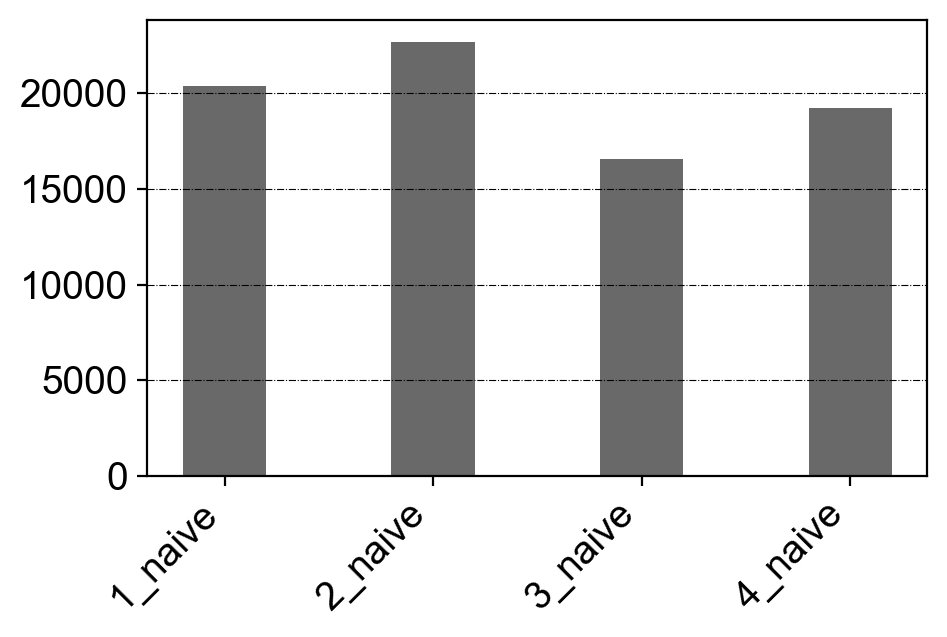

In [9]:
exp_list = []
counts_list = []
for adata in adatas:
    exp = adata.obs.experiment[0]
    counts = adata.n_obs
    exp_list.append(exp)
    counts_list.append(counts)

fig, ax = plt.subplots(figsize = (5, 3))

ax.bar(exp_list, counts_list, color ='dimgray', width = 0.4)
ax.set_xticklabels(exp_list)

ax.grid(False)
ax.grid(color='black', linestyle='-.', linewidth=0.4, axis='y')

for tick in ax.get_xticklabels():
    tick.set_ha('right')
    tick.set_rotation(45)

# Preprocessing

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


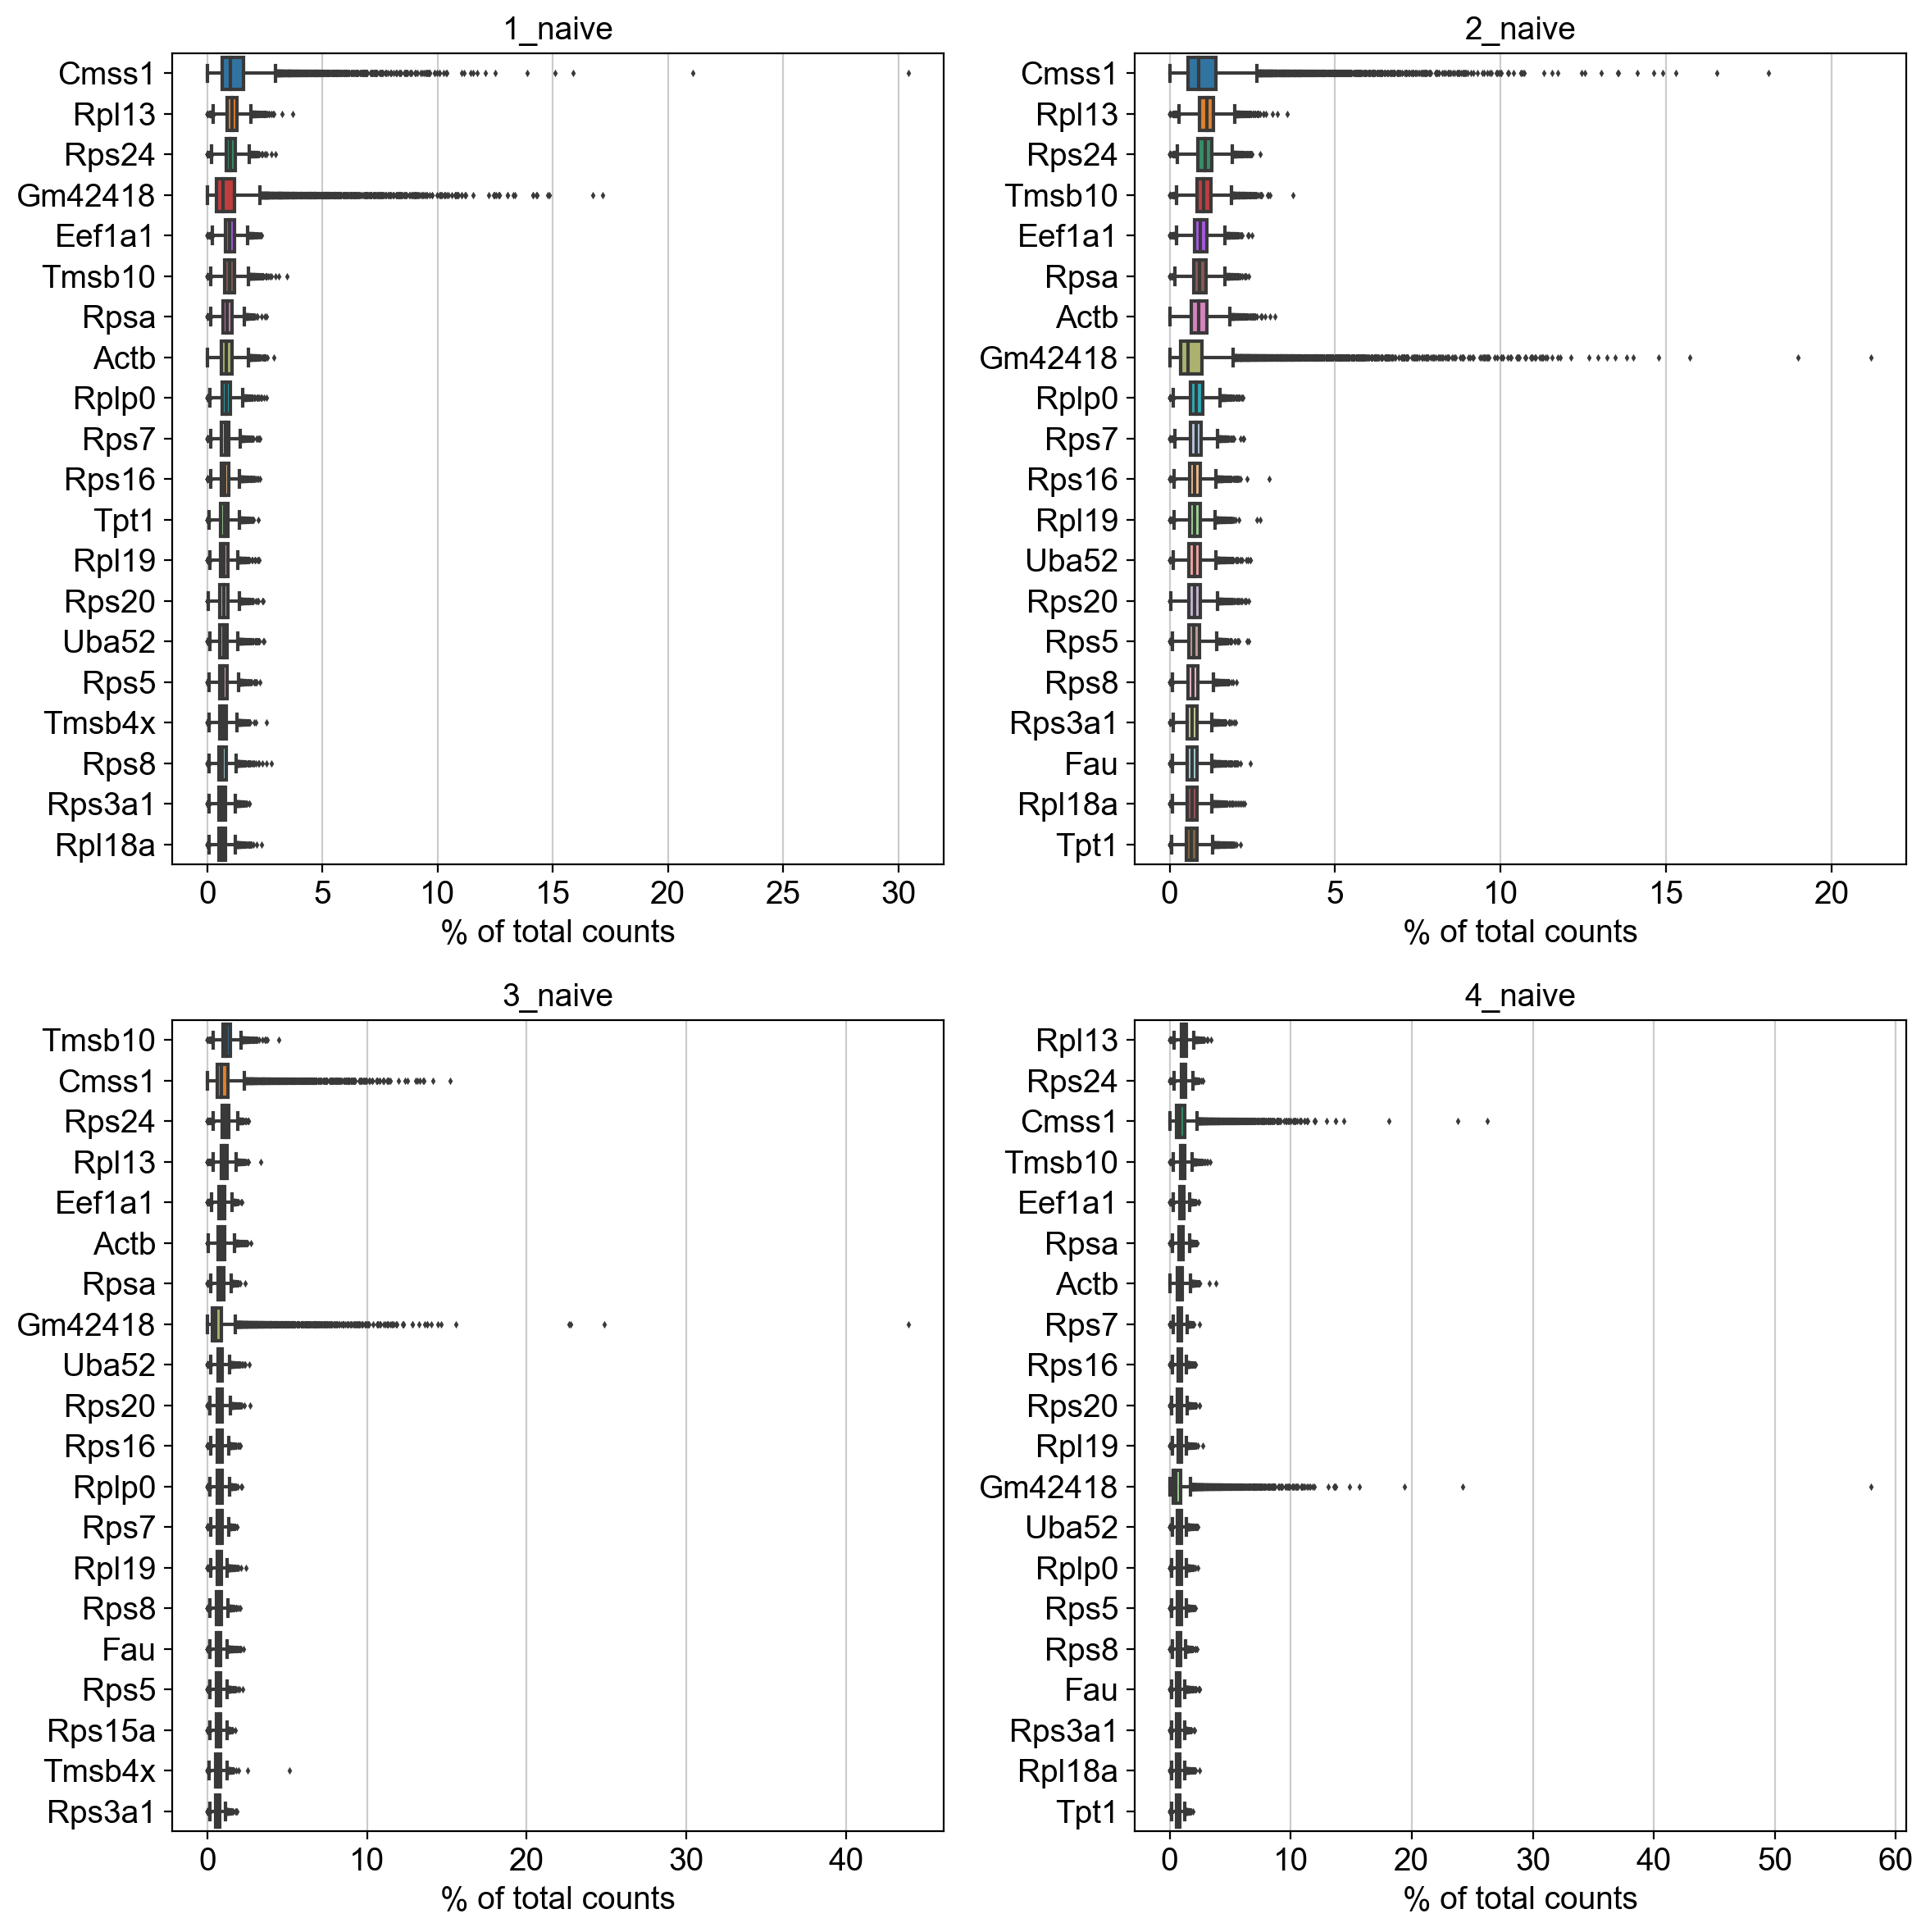

In [19]:
ncols = 2
nrows = len(adatas)//2
fig, ax = plt.subplots(nrows = nrows, ncols=ncols, figsize=(12, 3*len(adatas)))
#index = 0
#axis = 0

for i, adata in enumerate(adatas):
        sc.pl.highest_expr_genes(adata, n_top=20, ax=ax.reshape(-1)[i], show=False)
        ax.reshape(-1)[i].set_title(adata.obs.experiment[0])

fig.tight_layout()
plt.show() 

fig.savefig(save_figure_sc + 'highest_expr_genes.pdf')

### Basic filter

In the next step we will apply some bacic filters to these cells. Therefore we can control for the minimum number of genes per cell, to take this cell into account. A second filter will filter out genes, which are present in less than a certain number of cells.

In [20]:
for i, adata in enumerate(adatas):
    print(adatas[i].obs.experiment[0] + ' :Total number of cells: {:d}'.format(adatas[i].n_obs))
    sc.pp.filter_cells(adatas[i], min_genes=200)
    sc.pp.filter_genes(adata[i], min_cells=3)
    print(adatas[i].obs.experiment[0] +': Total number of cells after filtering: {:d}'.format(adatas[i].n_obs))

1_naive :Total number of cells: 20373
filtered out 1 cells that have less than 200 genes expressed
filtered out 32285 genes that are detected in less than 3 cells
1_naive: Total number of cells after filtering: 20372
2_naive :Total number of cells: 22705
filtered out 32285 genes that are detected in less than 3 cells
2_naive: Total number of cells after filtering: 22705
3_naive :Total number of cells: 16576
filtered out 32285 genes that are detected in less than 3 cells
3_naive: Total number of cells after filtering: 16576
4_naive :Total number of cells: 19250
filtered out 2 cells that have less than 200 genes expressed
filtered out 32285 genes that are detected in less than 3 cells
4_naive: Total number of cells after filtering: 19248


## Annotation of mouse samples

In [23]:
mouse_list = ['m1','m2','m3','m4']
for i, adata in enumerate(adatas):
    adatas[i].obs['mouse']=mouse_list[i]

Annotation of experimental conditions

In [24]:
for i, adata in enumerate(adatas):
    adatas[i].obs['batch']='unstim'

# Quality control

### Calculation of QC metrix

Compute number of deteced genes per cell, total counts per cell and percentage of mitochondrial genes per cell.

In [27]:
#rename
adatas_filtered = adatas

In [29]:
for i, adata in enumerate(adatas_filtered):
    # mitochondrial genes
    adatas_filtered[i].var["mt"] = adata.var_names.str.startswith("mt-")
    # ribosomal genes
    adatas_filtered[i].var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
    # hemoglobin genes.
    adatas_filtered[i].var["hb"] = adata.var_names.str.contains(("^hb[^(p)]"))

In [30]:
for i, adata in enumerate(adatas_filtered):
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
    )

In [31]:
#tcr_list = adata.var_names[(adata.var_names.str.startswith('TRBV')) | (adata.var_names.str.startswith('TRBJ')) |
#                    (adata.var_names.str.startswith('TRBD')) | (adata.var_names.str.startswith('TRAV')) |
#                    (adata.var_names.str.startswith('TRAJ'))].tolist()

In [32]:
#adatas_filtered[0].var_names[adatas_filtered[0].var_names.str.startswith("Mt")]

Plot quality control metrics

1_naive :


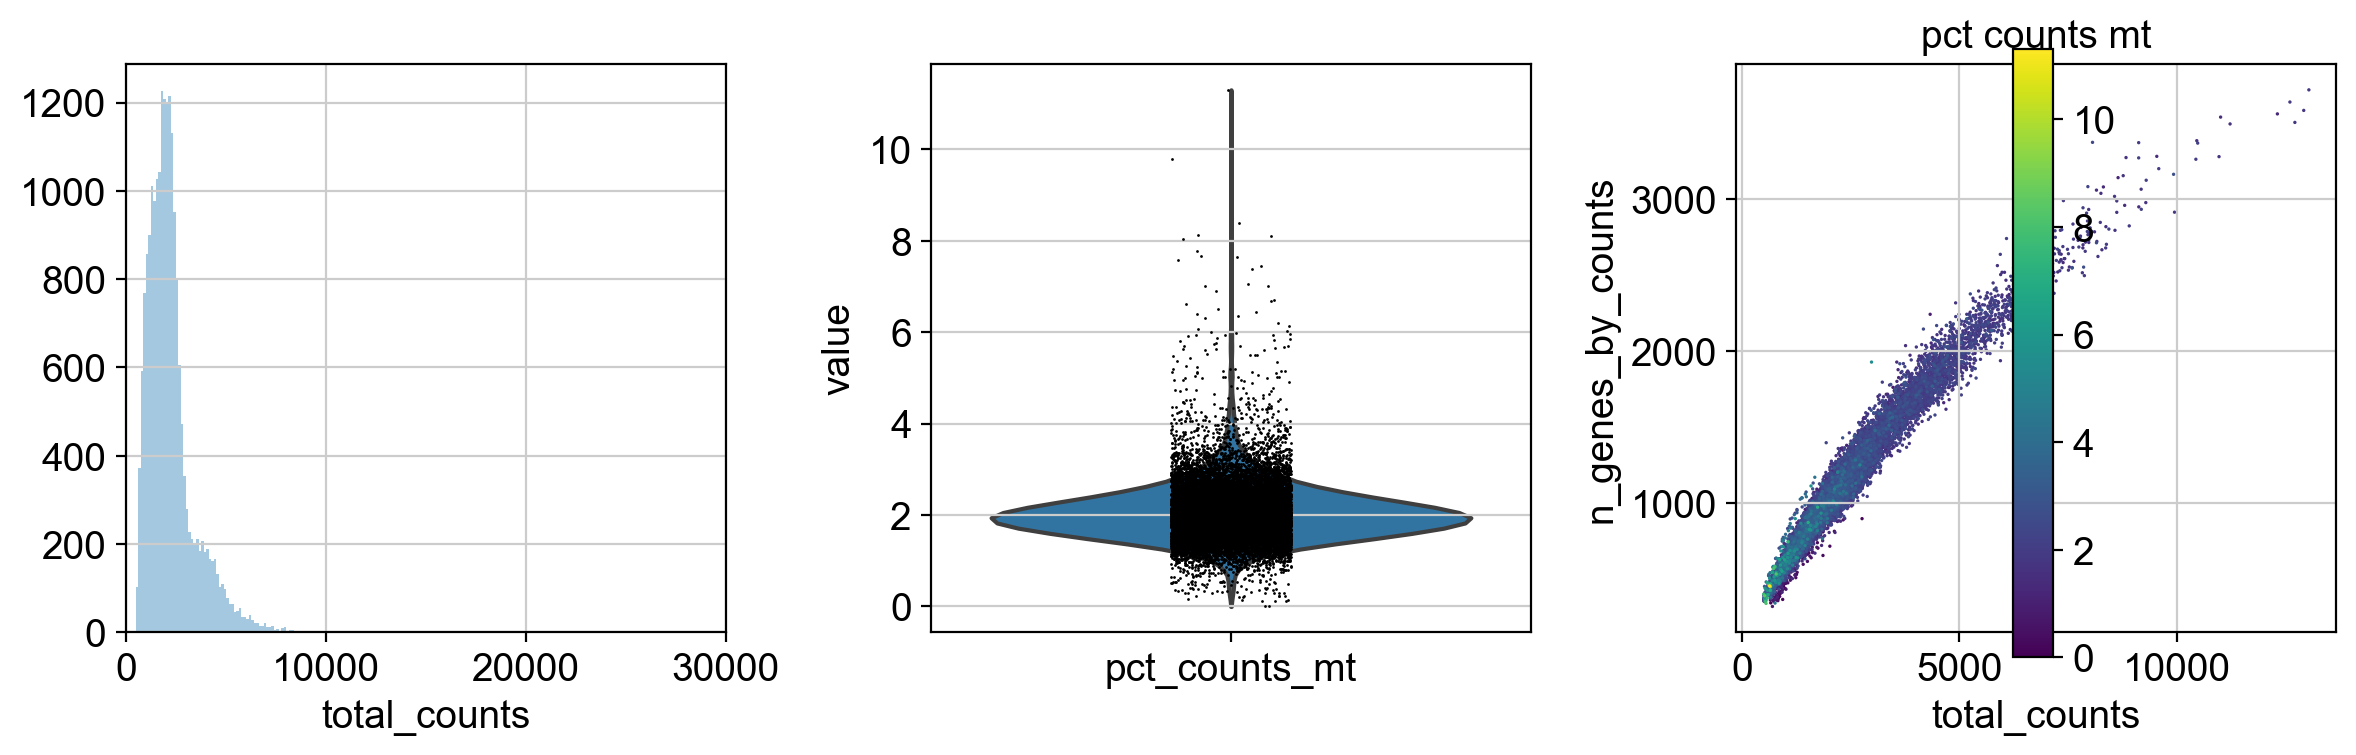

2_naive :


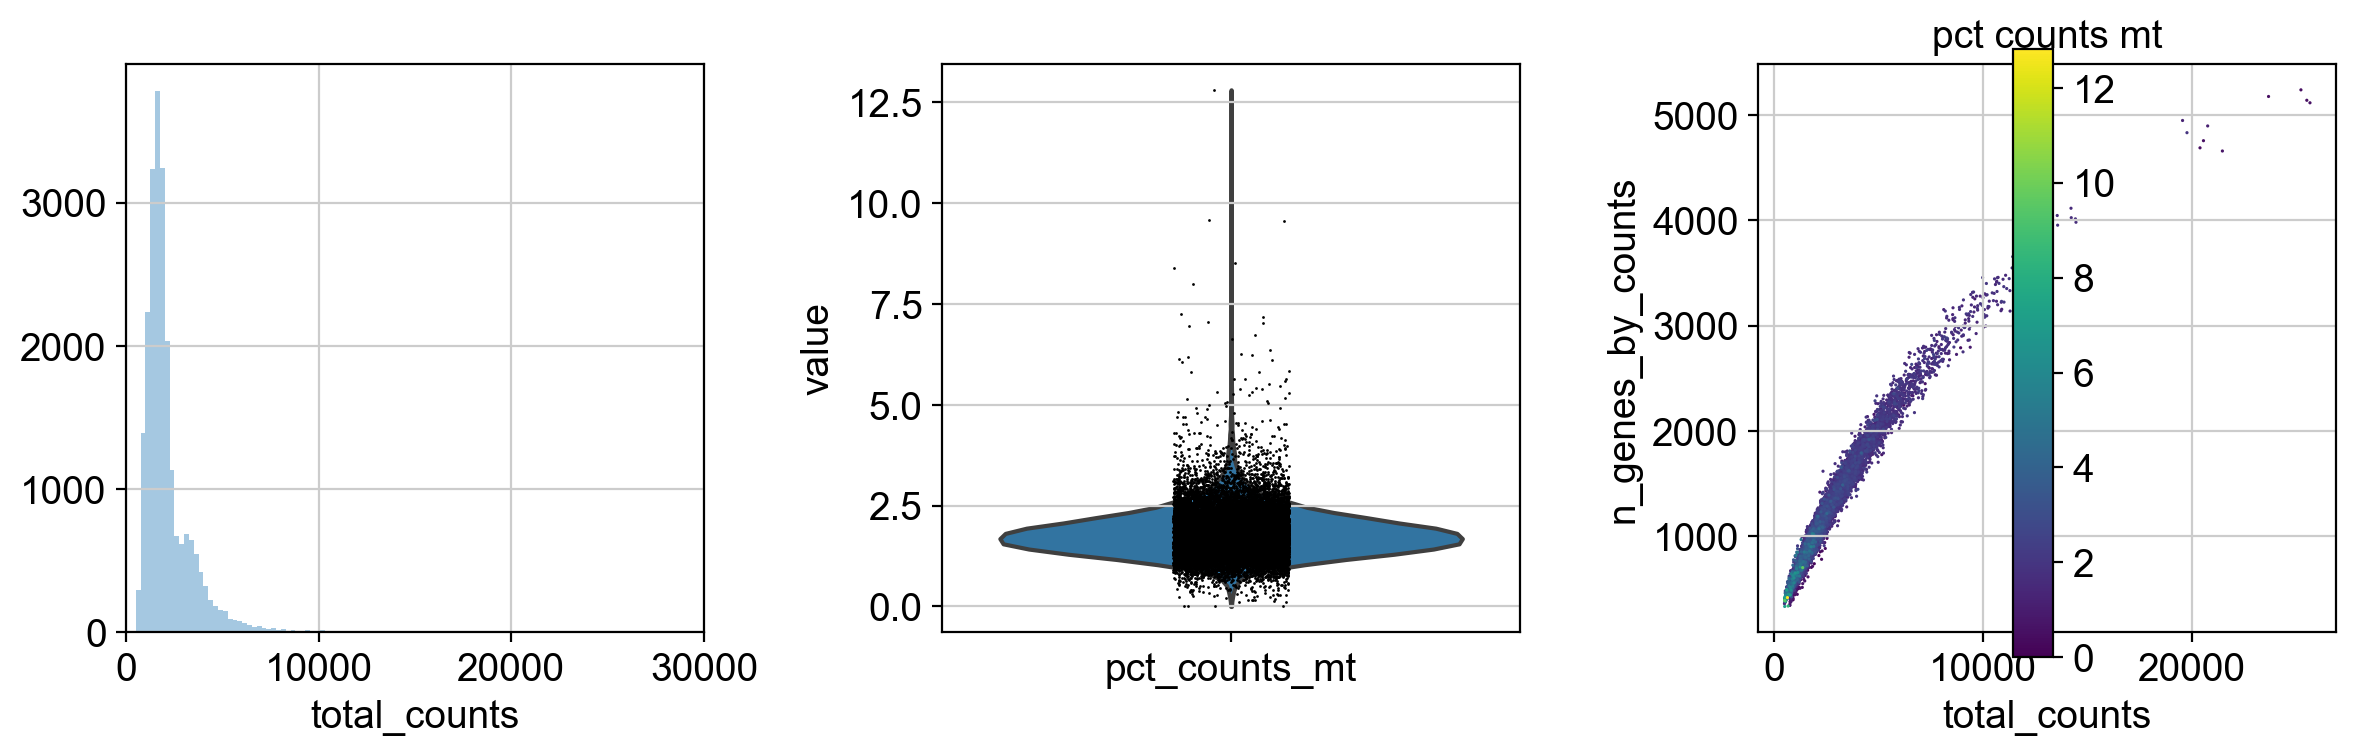

3_naive :


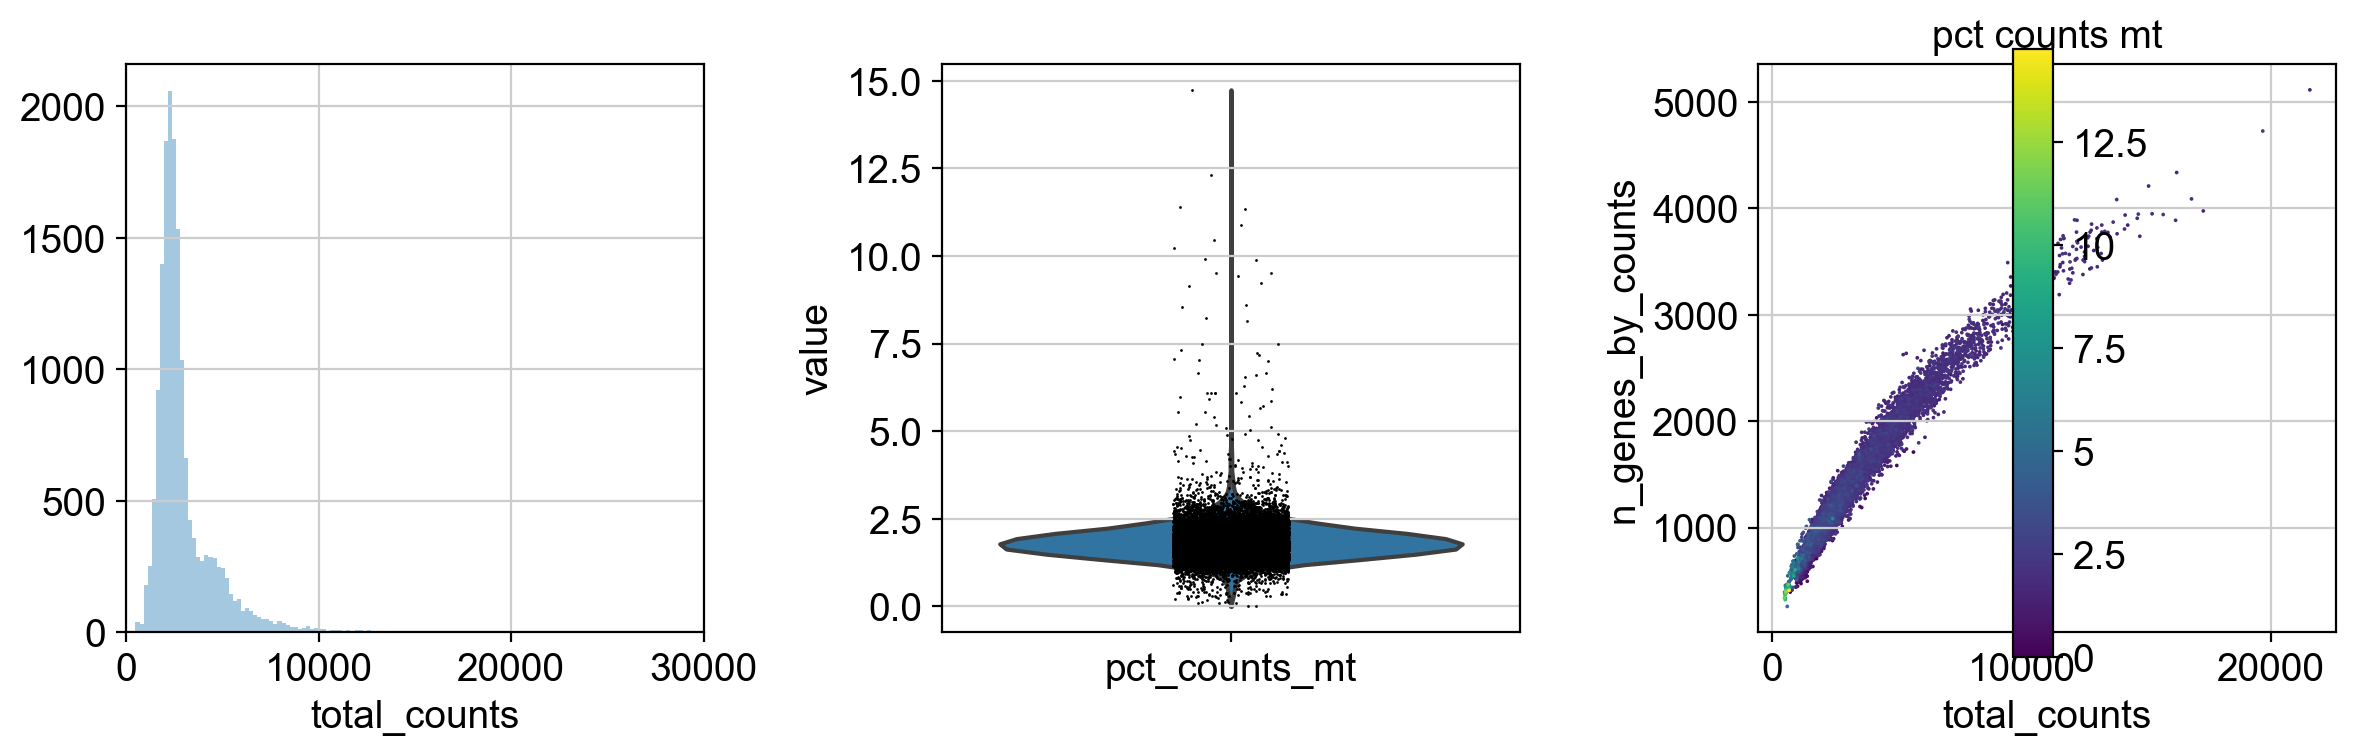

4_naive :


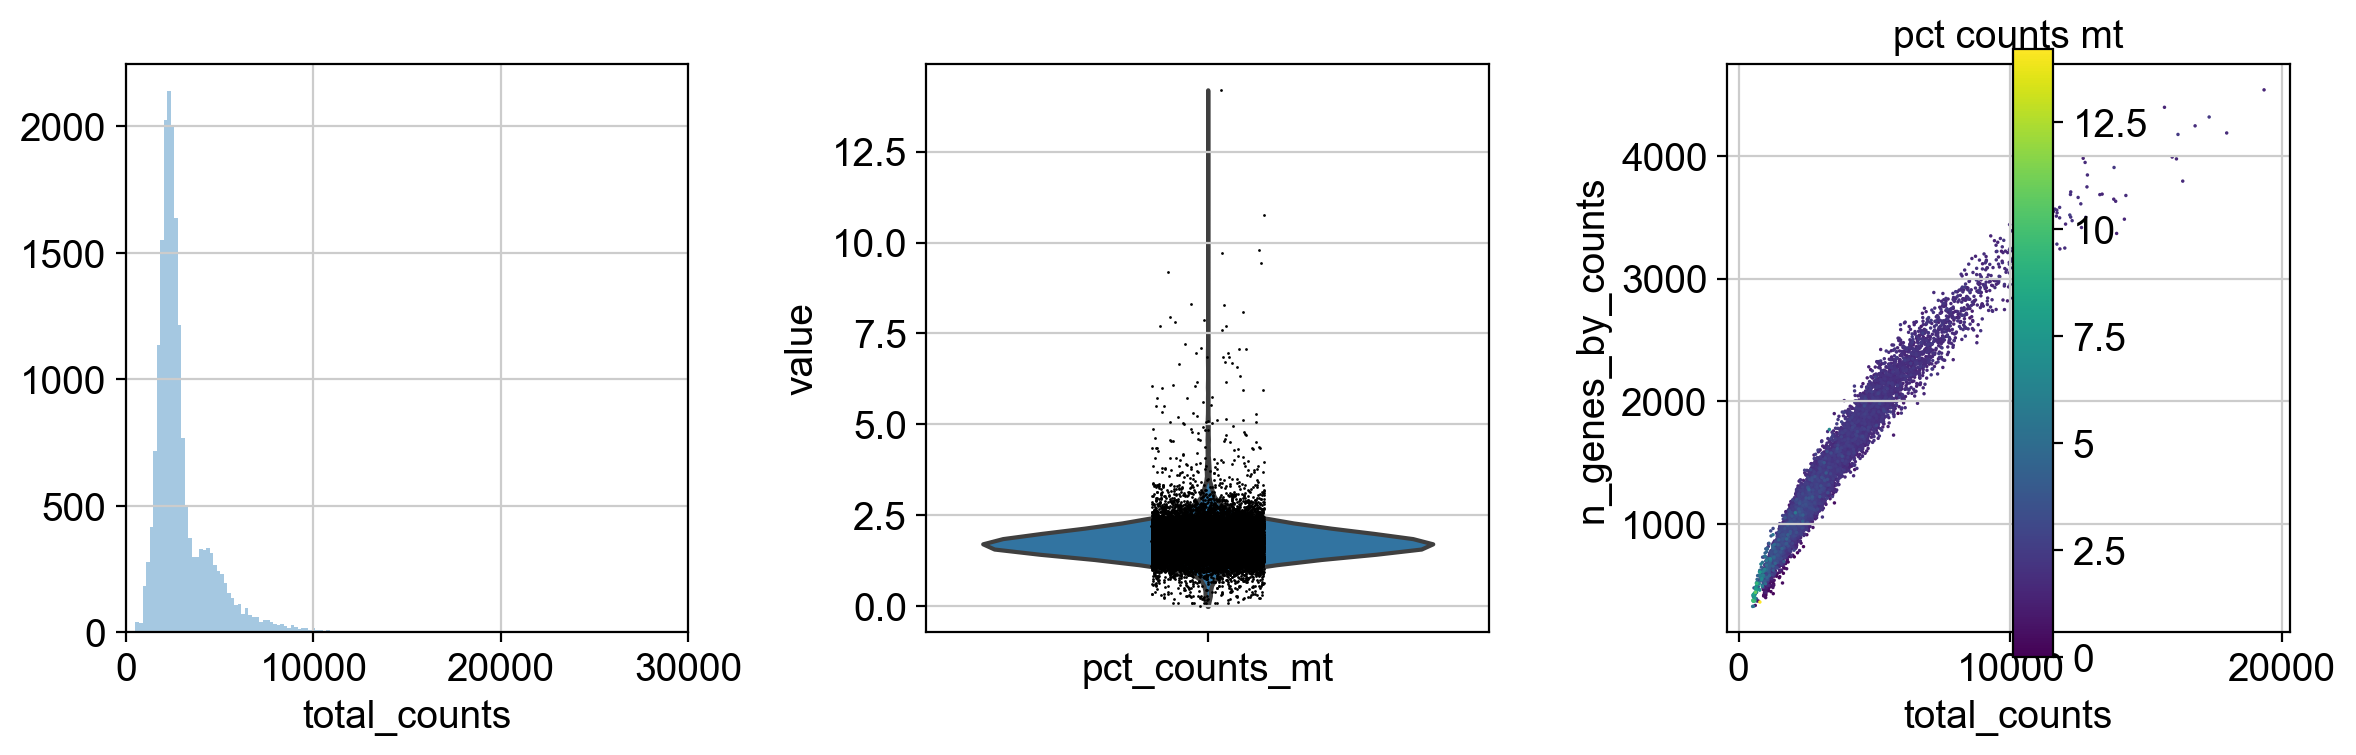

In [33]:
#fig, ax = plt.subplots(ncols=3, nrows=len(adatas))

for i, adata in enumerate(adatas_filtered):
    fig, ax = plt.subplots(ncols=3, figsize=(12,4))
    print(adata.obs.experiment[0], ":")
    sns.distplot(adata.obs["total_counts"], bins=100, kde=False, ax=ax[0])
    ax[0].set_xlim(0,30000)
    sc.pl.violin(adata, "pct_counts_mt", ax=ax[1], show=False)
    sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", ax=ax[2], show=False)
    fig.tight_layout() 
    plt.show()

                               

In [34]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [35]:
for adata in adatas_filtered:
    adata.obs["outlier"] = (
        is_outlier(adata, "log1p_total_counts", 5)
        | is_outlier(adata, "log1p_n_genes_by_counts", 5)
        | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    )
    print(adata.obs.outlier.value_counts())

False    20061
True       311
Name: outlier, dtype: int64
False    22150
True       555
Name: outlier, dtype: int64
False    15784
True       792
Name: outlier, dtype: int64
False    18463
True       785
Name: outlier, dtype: int64


In [36]:
for adata in adatas_filtered:
    adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 5) | (adata.obs["pct_counts_mt"] > 15)
    print(adata.obs.mt_outlier.value_counts())

False    20000
True       372
Name: mt_outlier, dtype: int64
False    22405
True       300
Name: mt_outlier, dtype: int64
False    16347
True       229
Name: mt_outlier, dtype: int64
False    18920
True       328
Name: mt_outlier, dtype: int64


Do filtering:

In [37]:
for i, adata in enumerate(adatas_filtered):
    print(f"Total number of cells: {adata.n_obs}")
    adatas_filtered[i] = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
    print(f"Number of cells after filtering of low quality cells: {adatas_filtered[i].n_obs}")

Total number of cells: 20372
Number of cells after filtering of low quality cells: 19747
Total number of cells: 22705
Number of cells after filtering of low quality cells: 21865
Total number of cells: 16576
Number of cells after filtering of low quality cells: 15643
Total number of cells: 19248
Number of cells after filtering of low quality cells: 18246


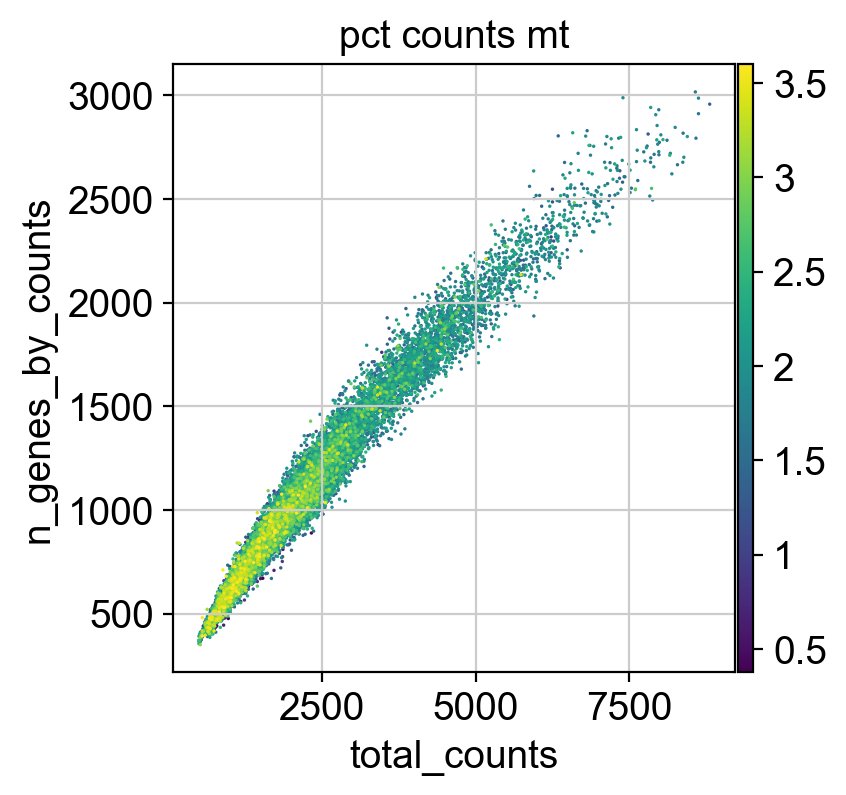

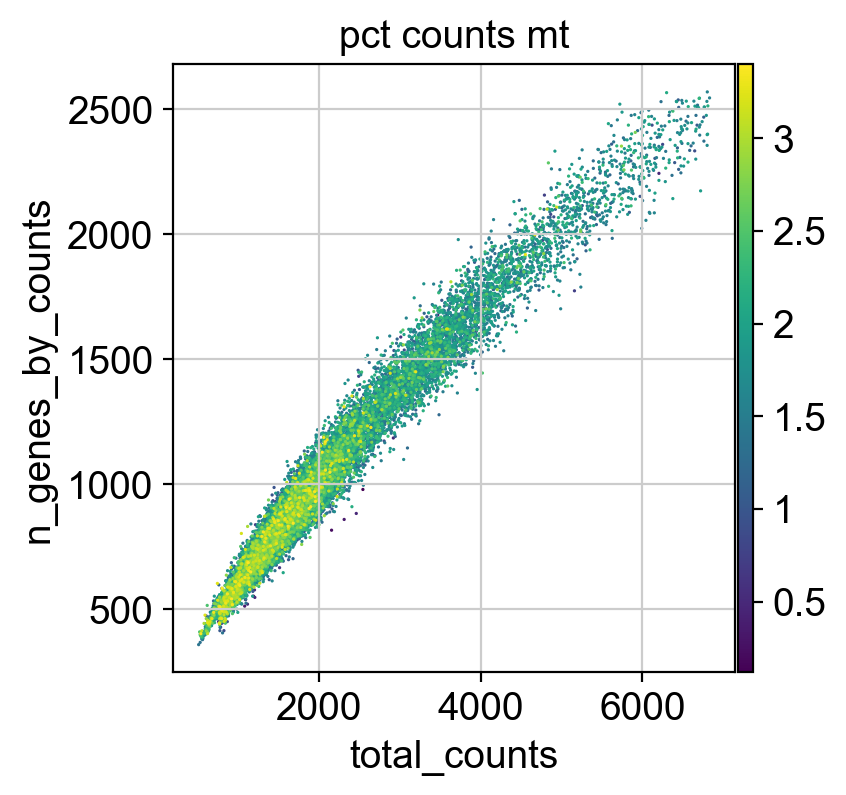

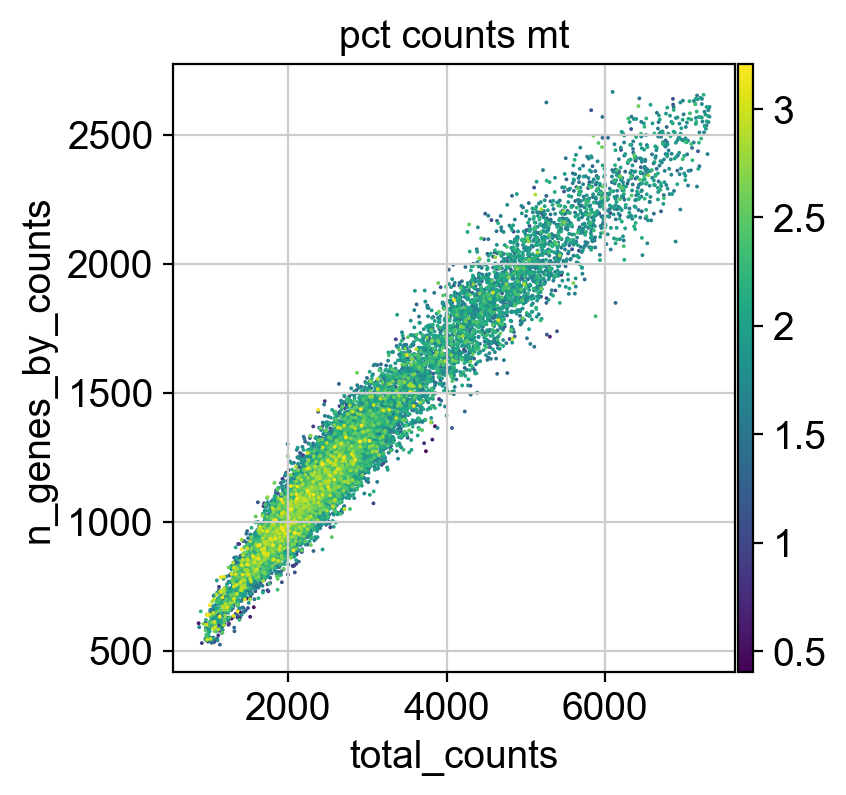

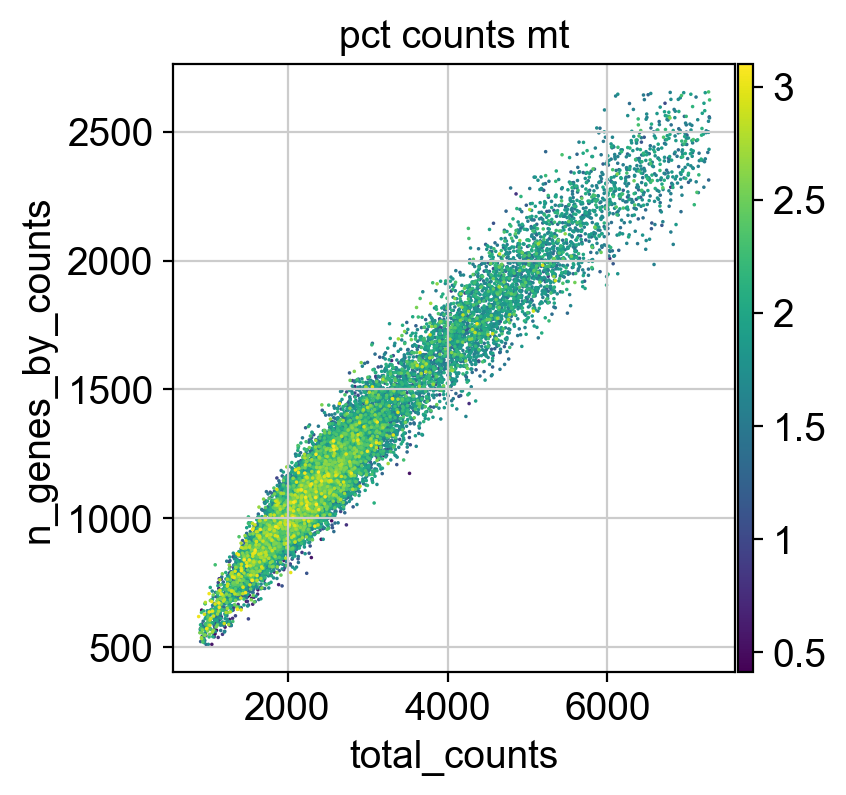

In [38]:
for adata in adatas_filtered:
    sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

SoupX package broken?

### Correction for ambient mRNA

In [39]:
import os
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.3.1'

import anndata2ri
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro


rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [40]:
#%%R
#install.packages("SoupX")

In [41]:
%%R
library(SoupX)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)
In addition: Warning message:
package 'SoupX' was built under R version 4.3.2 


In [42]:
adatas_pp = []
for adata in adatas_filtered:
    adata_pp = adata.copy()
    sc.pp.normalize_per_cell(adata_pp)
    sc.pp.log1p(adata_pp)
    adatas_pp.append(adata_pp)

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)


In [43]:
soupx_vectors = []
for adata_pp in adatas_pp:
    sc.pp.pca(adata_pp)
    sc.pp.neighbors(adata_pp)
    sc.tl.leiden(adata_pp, key_added="soupx_groups")

    # Preprocess variables for SoupX
    soupx_groups = adata_pp.obs["soupx_groups"]
    soupx_vectors.append(soupx_groups)

computing PCA
    with n_comps=50
    finished (0:00:41)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:28)
running Leiden clustering
    finished: found 9 clusters and added
    'soupx_groups', the cluster labels (adata.obs, categorical) (0:00:05)
computing PCA
    with n_comps=50
    finished (0:00:43)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 9 clusters and added
    'soupx_groups', the cluster labels (adata.obs, categorical) (0:00:09)
computing PCA
    with n_comps=50
    finished (0:00:38)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors

In [44]:
del adatas_pp

In [45]:
cell_list = []
gene_list = []
gex_list = []

for adata in adatas_filtered:
    cell_list.append(adata.obs_names)
    gene_list.append(adata.var_names)
    gex_list.append(adata.X.T)

In [46]:
adatas_raw = []

for sample, sample_meta in samples.items():
    raw_file=glob.glob(f'{sample_directory}/GEX*{sample}*/outs/raw_feature_bc_matrix.h5')[0]
    adata_raw = sc.read_10x_h5(filename=raw_file)
    
    adata_raw.var_names_make_unique()
    data_tod = adata_raw.X.T
    adatas_raw.append(data_tod)
    del adata_raw

reading ./gex_vdj\GEX_2\outs\raw_feature_bc_matrix.h5
 (0:00:01)
reading ./gex_vdj\GEX_3\outs\raw_feature_bc_matrix.h5
 (0:00:01)
reading ./gex_vdj\GEX_6\outs\raw_feature_bc_matrix.h5
 (0:00:01)
reading ./gex_vdj\GEX_7\outs\raw_feature_bc_matrix.h5
 (0:00:01)


In [47]:
import rpy2.robjects as robjects

soup_X_code = """
# Specify row and column names of data
rownames(data) <- genes
colnames(data) <- cells

# Convert to sparseMatrix format
library(Matrix)
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc <- SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf <- data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc <- setSoupProfile(sc, soupProf)

# Set cluster information in SoupChannel
sc <- setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc <- autoEstCont(sc, doPlot=FALSE)

# Infer corrected table of counts and round to integer
out <- adjustCounts(sc, roundToInt = TRUE)
"""

SoupX failed

Filter for minimum detected genes

In [49]:
for i, adata in enumerate(adatas_filtered):
    print(f"Total number of genes: {adata.n_vars}")

    # Min 20 cells - filters out 0 count genes
    sc.pp.filter_genes(adatas[i], min_cells=20)
    print(f"Number of genes after cell filter: {adatas_filtered[i].n_vars}")

Total number of genes: 32285
filtered out 19969 genes that are detected in less than 20 cells
Number of genes after cell filter: 12316
Total number of genes: 32285
filtered out 20023 genes that are detected in less than 20 cells
Number of genes after cell filter: 12262
Total number of genes: 32285
filtered out 20029 genes that are detected in less than 20 cells
Number of genes after cell filter: 12256
Total number of genes: 32285
filtered out 19993 genes that are detected in less than 20 cells
Number of genes after cell filter: 12292


### Doublet detection

In [50]:
#%%R
#install.packages("Seurat")

In [51]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)

Loading required package: SeuratObject
Loading required package: sp

Attaching package: 'SeuratObject'

The following object is masked from 'package:base':

    intersect

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: 'MatrixGenerics'

The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowC

Run doublet finder

In [52]:
doublet_code = """

set.seed(123)
sce <- scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score <- sce$scDblFinder.score
doublet_class <- sce$scDblFinder.class

"""

Package failed

### Store adata to file

In [54]:
for i, adata in enumerate(adatas_filtered):
    adata_file = adata.obs.experiment[0]
    adatas_filtered[i].write(adata_directory + "01_" + adata_file + "_QC_proc.h5ad")